In [23]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

### Análise de Dados da Base de falhas

In [24]:
df = pd.read_csv("../assets/ai4i2020.csv")
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Informações sobre a base

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

### Percentual de Falhas

In [26]:
df["Machine failure"].value_counts()

df["Machine failure"].value_counts(normalize=True)*100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

### Tipos de Máquina por número de Falhas

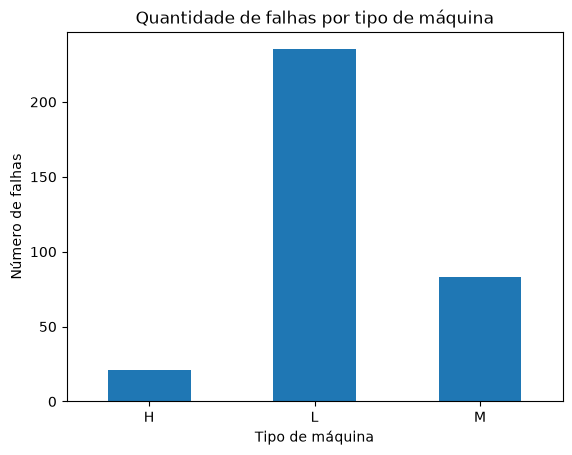

In [27]:
falhas_tipo = (
    df[df["Machine failure"] == 1]
    .groupby("Type")
    .size()
)

falhas_tipo.plot(kind="bar")
plt.title("Quantidade de falhas por tipo de máquina")
plt.xlabel("Tipo de máquina")
plt.ylabel("Número de falhas")
plt.xticks(rotation=0)
plt.show()

### Contagem de tipos de falhas

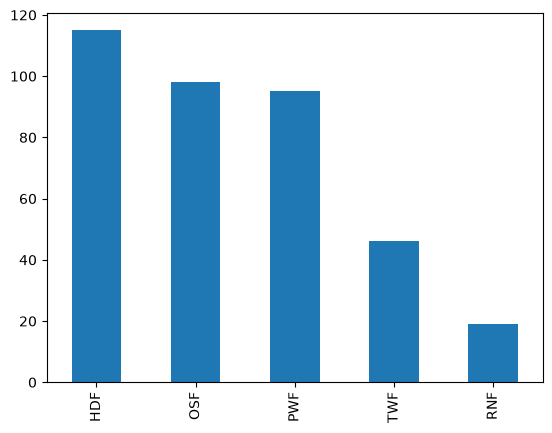

In [28]:
features_types_failures = ["TWF","HDF","PWF","OSF","RNF"]

table_failures = df[features_types_failures].sum().sort_values(ascending=False).plot(kind="bar")

### Probabilidade de Falha por features importantes

#### Probabilidade de Falha por torque

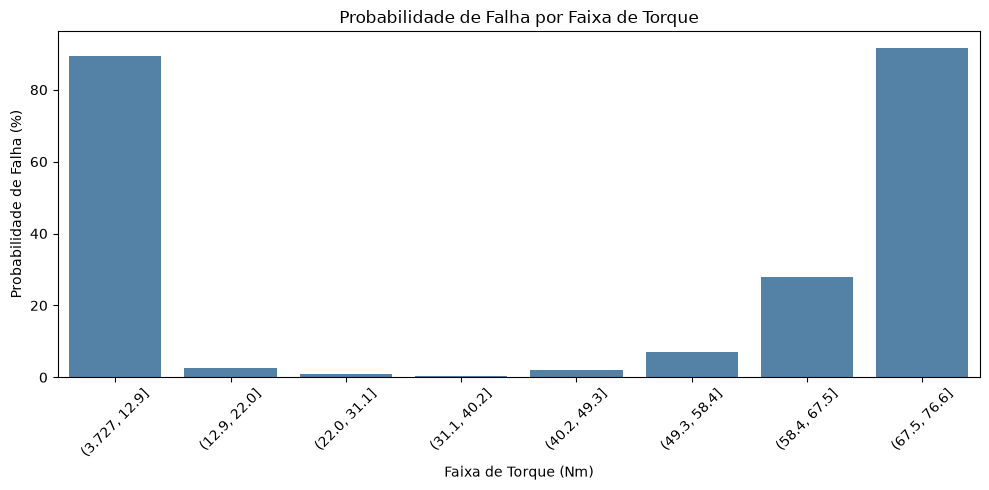

In [29]:
import pandas as pd

df["Torque_bin"] = pd.cut(
    df["Torque [Nm]"],
    bins=8  
)

prob_torque = (
    df.groupby("Torque_bin", observed=False)["Machine failure"]
      .mean()
      .mul(100)
      .reset_index(name="Failure Probability (%)")
).sort_values('Torque_bin')


plt.figure(figsize=(10,5))

sns.barplot(
    data=prob_torque,
    x="Torque_bin",
    y="Failure Probability (%)",
    color="steelblue"
)

plt.xticks(rotation=45)
plt.xlabel("Faixa de Torque (Nm)")
plt.ylabel("Probabilidade de Falha (%)")
plt.title("Probabilidade de Falha por Faixa de Torque")
plt.tight_layout()
plt.show()

#### Probabilidade de Falha por Tool Wear

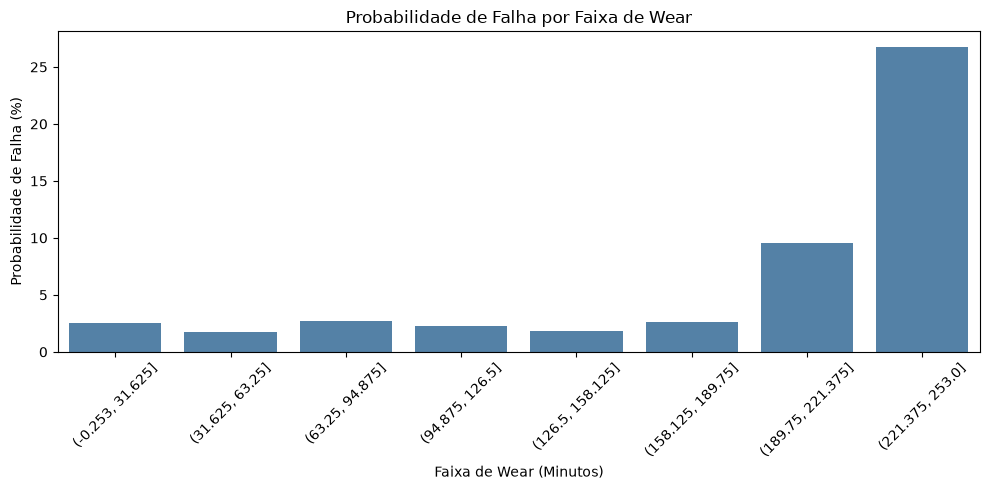

In [30]:
import pandas as pd

df["Tool wear [min]"] = pd.cut(
    df["Tool wear [min]"],
    bins=8  
)

prob_tool_wear = (
    df.groupby("Tool wear [min]", observed=False)["Machine failure"]
      .mean()
      .mul(100)
      .reset_index(name="Failure Probability (%)")
).sort_values('Tool wear [min]')


plt.figure(figsize=(10,5))

sns.barplot(
    data=prob_tool_wear,
    x="Tool wear [min]",
    y="Failure Probability (%)",
    color="steelblue"
)

plt.xticks(rotation=45)
plt.xlabel("Faixa de Wear (Minutos)")
plt.ylabel("Probabilidade de Falha (%)")
plt.title("Probabilidade de Falha por Faixa de Wear")
plt.tight_layout()
plt.show()

#### Probabilidade de Falha por Rotational Speed

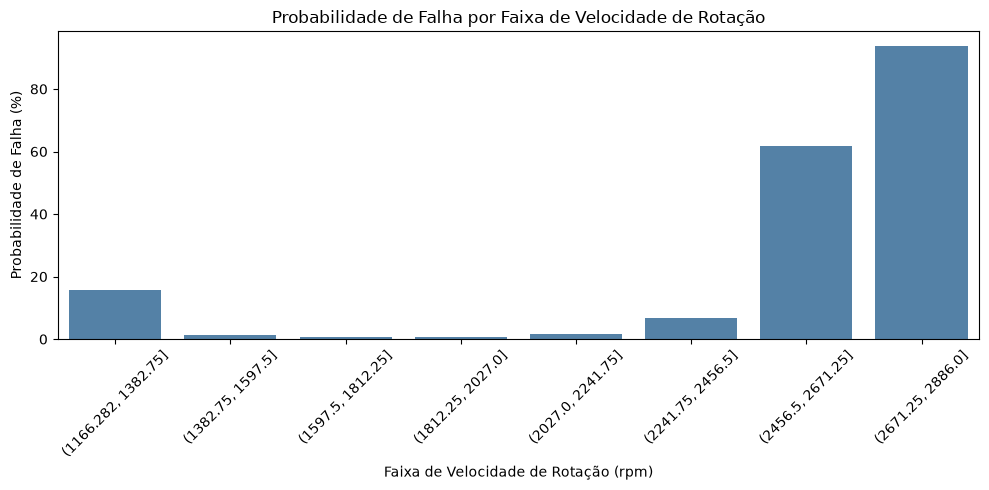

In [31]:
import pandas as pd

df["Rotational speed [rpm]"] = pd.cut(
    df["Rotational speed [rpm]"],
    bins=8  
)

prob_rotational_speed = (
    df.groupby("Rotational speed [rpm]", observed=False)["Machine failure"]
      .mean()
      .mul(100)
      .reset_index(name="Failure Probability (%)")
).sort_values('Rotational speed [rpm]')


plt.figure(figsize=(10,5))

sns.barplot(
    data=prob_rotational_speed,
    x="Rotational speed [rpm]",
    y="Failure Probability (%)",
    color="steelblue"
)

plt.xticks(rotation=45)
plt.xlabel("Faixa de Velocidade de Rotação (rpm)")
plt.ylabel("Probabilidade de Falha (%)")
plt.title("Probabilidade de Falha por Faixa de Velocidade de Rotação")
plt.tight_layout()
plt.show()